In [67]:
import cv2
import os

# Dataset paths
crack_path = "448/Cracks"
noncrack_path = "448/NonCracks"

# Store images and labels
images = []
labels = []

# Load Crack images
for filename in os.listdir(crack_path):
    image_path = os.path.join(crack_path, filename)
    
    image = cv2.imread(image_path)
    
    if image is not None:
        images.append(image)
        labels.append(1)

# Load Non-Crack images
for filename in os.listdir(noncrack_path):
    image_path = os.path.join(noncrack_path, filename)
    
    image = cv2.imread(image_path)
    
    if image is not None:
        images.append(image)
        labels.append(0)

print("Total images:", len(images))
print("Total labels:", len(labels))
print("Crack images:", labels.count(1))
print("Non-crack images:", labels.count(0))

Total images: 400
Total labels: 400
Crack images: 200
Non-crack images: 200


In [68]:
print(images)

[array([[[102, 111, 114],
        [ 69,  74,  77],
        [108, 101, 104],
        ...,
        [ 71,  77,  84],
        [ 91, 100, 110],
        [ 88,  97, 110]],

       [[123, 132, 135],
        [112, 116, 117],
        [127, 122, 124],
        ...,
        [109, 115, 122],
        [ 86,  95, 105],
        [ 67,  77,  87]],

       [[127, 135, 135],
        [116, 120, 121],
        [106, 101, 103],
        ...,
        [110, 116, 123],
        [100, 107, 116],
        [ 90,  99, 108]],

       ...,

       [[122, 125, 133],
        [168, 170, 178],
        [157, 157, 163],
        ...,
        [108, 103, 100],
        [101,  97,  96],
        [ 78,  76,  75]],

       [[135, 142, 151],
        [163, 169, 176],
        [152, 156, 161],
        ...,
        [137, 133, 132],
        [111, 109, 109],
        [ 81,  81,  81]],

       [[131, 140, 149],
        [156, 164, 171],
        [146, 152, 159],
        ...,
        [119, 117, 117],
        [105, 104, 106],
        [104, 106, 107]

In [69]:
print(images[0].shape)     # (448, 448, 3)
print(images[0].dtype)     # uint8
print(images[0][0][0])     # first pixel: [102 111 114]
print(len(images))         # 400

(448, 448, 3)
uint8
[102 111 114]
400


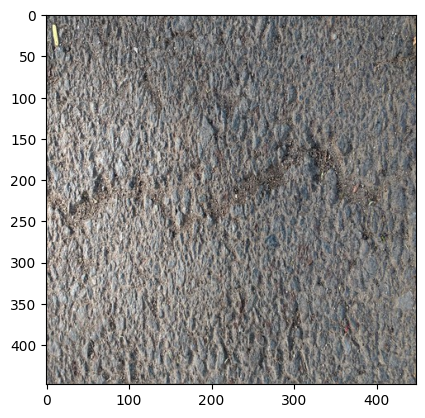

In [70]:
import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(images[0], cv2.COLOR_BGR2RGB))
plt.show()

In [71]:
# Inspect dimensions and channels of the first 10 images

for i in range(min(10, len(images))):
    height, width, channels = images[i].shape
    
    print(f"Image {i + 1}:")
    print("Height:", height)
    print("Width:", width)
    print("Channels:", channels)
    print()

Image 1:
Height: 448
Width: 448
Channels: 3

Image 2:
Height: 448
Width: 448
Channels: 3

Image 3:
Height: 448
Width: 448
Channels: 3

Image 4:
Height: 448
Width: 448
Channels: 3

Image 5:
Height: 448
Width: 448
Channels: 3

Image 6:
Height: 448
Width: 448
Channels: 3

Image 7:
Height: 448
Width: 448
Channels: 3

Image 8:
Height: 448
Width: 448
Channels: 3

Image 9:
Height: 448
Width: 448
Channels: 3

Image 10:
Height: 448
Width: 448
Channels: 3



In [72]:
# Check unique image shapes

shapes = set(image.shape for image in images)

print("Unique image shapes:")
for shape in shapes:
    print(shape)

Unique image shapes:
(448, 448, 3)


In [73]:
# Convert all images to grayscale

gray_images = []

for image in images:
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray_images.append(gray_image)

print("Number of grayscale images:", len(gray_images))
print("Grayscale image shape:", gray_images[0].shape)

Number of grayscale images: 400
Grayscale image shape: (448, 448)


In [74]:
import numpy as np
import pandas as pd

features = []

for image in gray_images:
    
    # Mean brightness
    mean_brightness = np.mean(image)
    
    # Contrast
    contrast = np.std(image)
    
    # Dark-pixel ratio
    dark_pixel_ratio = np.mean(image < 50)
    
    # Bright-pixel ratio
    bright_pixel_ratio = np.mean(image > 200)
    
    # Minimum and maximum intensity
    min_intensity = np.min(image)
    max_intensity = np.max(image)
    
    # Median intensity
    median_intensity = np.median(image)
    
    # Store features
    features.append([
        mean_brightness,
        contrast,
        dark_pixel_ratio,
        bright_pixel_ratio,
        min_intensity,
        max_intensity,
        median_intensity
    ])

# Create feature DataFrame
feature_df = pd.DataFrame(
    features,
    columns=[
        "mean_brightness",
        "contrast",
        "dark_pixel_ratio",
        "bright_pixel_ratio",
        "min_intensity",
        "max_intensity",
        "median_intensity"
    ]
)

print(feature_df.head())

   mean_brightness   contrast  dark_pixel_ratio  bright_pixel_ratio  \
0       122.096147  38.014345          0.016333            0.026676   
1       131.822704  29.319148          0.006741            0.011759   
2       121.171217  35.572563          0.024992            0.020712   
3       130.117701  32.745086          0.008889            0.014917   
4       131.079998  33.199356          0.009741            0.016791   

   min_intensity  max_intensity  median_intensity  
0              0            255             121.0  
1              0            255             133.0  
2              0            255             120.0  
3              1            255             131.0  
4              0            255             132.0  


In [75]:
# Extract Canny edge features

edge_features = []

for image in gray_images:
    
    # Apply Canny edge detection
    blurred = cv2.GaussianBlur(image, (5, 5), 0) # removes tine false noise edges
    edges = cv2.Canny(blurred, 100, 200)
    
    # Count edge pixels
    edge_count = np.sum(edges > 0)
    
    # Calculate edge density
    total_pixels = image.shape[0] * image.shape[1]
    edge_density = edge_count / total_pixels
    
    edge_features.append([
        edge_count,
        edge_density
    ])

# Add Canny features to the feature DataFrame
feature_df["edge_count"] = [x[0] for x in edge_features]
feature_df["edge_density"] = [x[1] for x in edge_features]

print(feature_df.head())

   mean_brightness   contrast  dark_pixel_ratio  bright_pixel_ratio  \
0       122.096147  38.014345          0.016333            0.026676   
1       131.822704  29.319148          0.006741            0.011759   
2       121.171217  35.572563          0.024992            0.020712   
3       130.117701  32.745086          0.008889            0.014917   
4       131.079998  33.199356          0.009741            0.016791   

   min_intensity  max_intensity  median_intensity  edge_count  edge_density  
0              0            255             121.0       32198      0.160425  
1              0            255             133.0       11361      0.056606  
2              0            255             120.0       23042      0.114806  
3              1            255             131.0       22155      0.110386  
4              0            255             132.0       23572      0.117447  


In [76]:
import cv2
import matplotlib.pyplot as plt
import os

# Get one crack image
filename = os.listdir("448/Cracks")[10]
image_path = os.path.join("448/Cracks", filename)

# Read original image
image = cv2.imread(image_path)

# Convert BGR to RGB for correct matplotlib display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Apply Canny Edge Detection
canny = cv2.Canny(blurred, 50, 150)

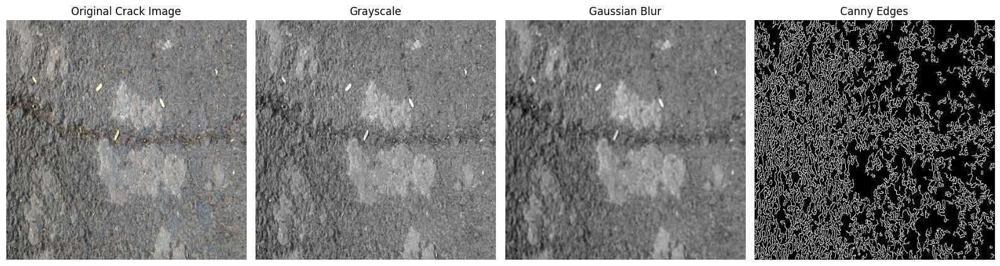

In [77]:
plt.figure(figsize=(16, 5))

# Original
plt.subplot(1, 4, 1)
plt.imshow(image_rgb)
plt.title("Original Crack Image")
plt.axis("off")

# Grayscale
plt.subplot(1, 4, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

# Gaussian Blur
plt.subplot(1, 4, 3)
plt.imshow(blurred, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

# Canny
plt.subplot(1, 4, 4)
plt.imshow(canny, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.tight_layout()
plt.show()

In [268]:
import numpy as np
import pandas as pd
import cv2
from sklearn.model_selection import train_test_split

BASE_COLS = ["mean_brightness", "contrast", "dark_pixel_ratio",
             "bright_pixel_ratio", "min_intensity", "max_intensity",
             "median_intensity", "edge_count", "edge_density"]

def baseline_features(gray, low=100, high=200):
    intensity = [np.mean(gray), np.std(gray), np.mean(gray < 50),
                 np.mean(gray > 200), np.min(gray), np.max(gray),
                 np.median(gray)]
    edges = cv2.Canny(cv2.GaussianBlur(gray, (5, 5), 0), low, high)
    count = int(np.sum(edges > 0))
    return intensity + [count, count / edges.size]

X_base = pd.DataFrame([baseline_features(g) for g in gray_images],
                      columns=BASE_COLS)
y_base = np.array(labels)

assert "label" not in X_base.columns
assert len(X_base) == len(y_base) == 400
print(X_base.shape, "| class counts:", np.bincount(y_base))

X_base.assign(label=y_base).to_csv("image_features_baseline.csv", index=False)

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_base, y_base, test_size=0.2, stratify=y_base, random_state=42
)
print(Xb_train.shape, Xb_test.shape)

(400, 9) | class counts: [200 200]
(320, 9) (80, 9)


In [269]:
import time
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

base_models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=1000)),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=4, min_samples_leaf=5, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=6, min_samples_leaf=3,
        max_features="sqrt", random_state=42),
}

base_results = {}
for name, model in base_models.items():
    start = time.perf_counter()
    model.fit(Xb_train, yb_train)
    train_time = time.perf_counter() - start

    start = time.perf_counter()
    pred = model.predict(Xb_test)
    predict_time = time.perf_counter() - start

    base_results[name] = {"model": model, "pred": pred,
                          "train_time": train_time,
                          "predict_time": predict_time}
    print(f"{name:22s} train={train_time:.4f}s  predict={predict_time:.4f}s")

Logistic Regression    train=0.0098s  predict=0.0023s
Decision Tree          train=0.0033s  predict=0.0023s
Random Forest          train=0.3796s  predict=0.0113s


In [270]:
import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

rows = []
for name, r in base_results.items():
    model, pred = r["model"], r["pred"]
    train_acc = accuracy_score(yb_train, model.predict(Xb_train))
    test_acc = accuracy_score(yb_test, pred)
    rows.append([name, train_acc, test_acc,
                 precision_score(yb_test, pred), recall_score(yb_test, pred),
                 f1_score(yb_test, pred), train_acc - test_acc,
                 r["train_time"], r["predict_time"]])
    print(name, "\n", confusion_matrix(yb_test, pred), "\n")

base_results_df = pd.DataFrame(rows, columns=[
    "Model", "Train Acc", "Test Acc", "Precision", "Recall",
    "F1", "Train-Test Gap", "Train Time", "Predict Time"])
base_results_df

Logistic Regression 
 [[36  4]
 [ 2 38]] 

Decision Tree 
 [[38  2]
 [ 4 36]] 

Random Forest 
 [[38  2]
 [ 1 39]] 



,Model,Train Acc,Test Acc,Precision,Recall,F1,Train-Test Gap,Train Time,Predict Time
0,Logistic Regression,0.900000,0.9250,0.904762,0.950,0.926829,-0.025000,0.009772,0.002323
1,Decision Tree,0.956250,0.9250,0.947368,0.900,0.923077,0.031250,0.003272,0.002268
2,Random Forest,0.978125,0.9625,0.951220,0.975,0.962963,0.015625,0.379557,0.011298


In [267]:
print(list(X_base.columns))

['mean_brightness', 'contrast', 'dark_pixel_ratio', 'bright_pixel_ratio', 'min_intensity', 'max_intensity', 'median_intensity', 'crack_pixel_count', 'crack_pixel_ratio', 'num_components', 'largest_component', 'label']


In [78]:
# Create CLAHE
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

# Apply CLAHE
enhanced_gray = clahe.apply(gray)

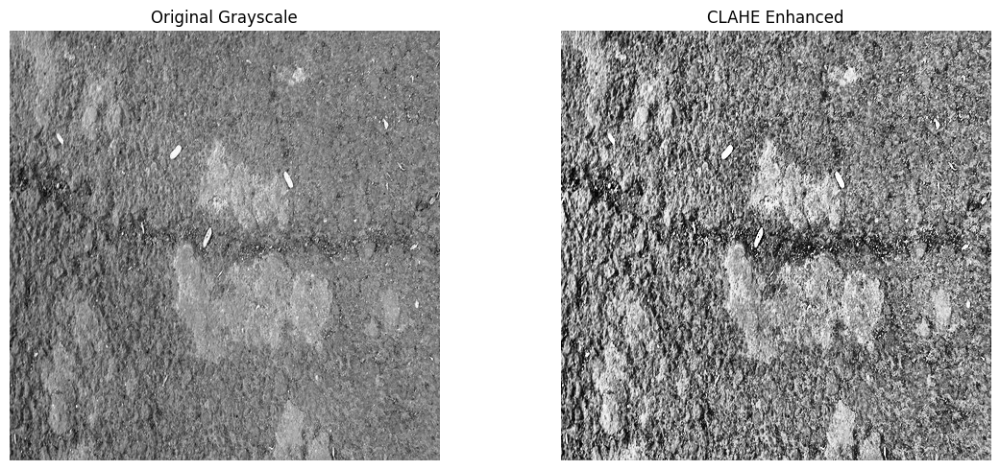

In [79]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(enhanced_gray, cmap="gray")
plt.title("CLAHE Enhanced")
plt.axis("off")

plt.tight_layout()
plt.show()

In [80]:
# Apply CLAHE to grayscale image
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

enhanced_gray = clahe.apply(gray)

# Create Black Hat kernel
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (15, 15)
)

# Apply Black Hat on CLAHE image
blackhat = cv2.morphologyEx(
    enhanced_gray,
    cv2.MORPH_BLACKHAT,
    kernel
)

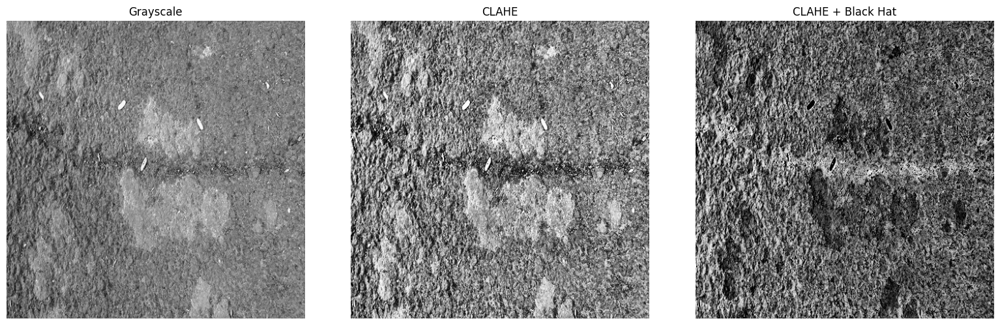

In [81]:
plt.figure(figsize=(16, 5))

# Original grayscale
plt.subplot(1, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

# CLAHE
plt.subplot(1, 3, 2)
plt.imshow(enhanced_gray, cmap="gray")
plt.title("CLAHE")
plt.axis("off")

# Black Hat
plt.subplot(1, 3, 3)
plt.imshow(blackhat, cmap="gray")
plt.title("CLAHE + Black Hat")
plt.axis("off")

plt.tight_layout()
plt.show()

In [82]:
kernel_9 = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
kernel_15 = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
kernel_21 = cv2.getStructuringElement(cv2.MORPH_RECT, (21, 21))
kernel_31 = cv2.getStructuringElement(cv2.MORPH_RECT, (31, 31))

bh_9 = cv2.morphologyEx(enhanced_gray, cv2.MORPH_BLACKHAT, kernel_9)
bh_15 = cv2.morphologyEx(enhanced_gray, cv2.MORPH_BLACKHAT, kernel_15)
bh_21 = cv2.morphologyEx(enhanced_gray, cv2.MORPH_BLACKHAT, kernel_21)
bh_31 = cv2.morphologyEx(enhanced_gray, cv2.MORPH_BLACKHAT, kernel_31)

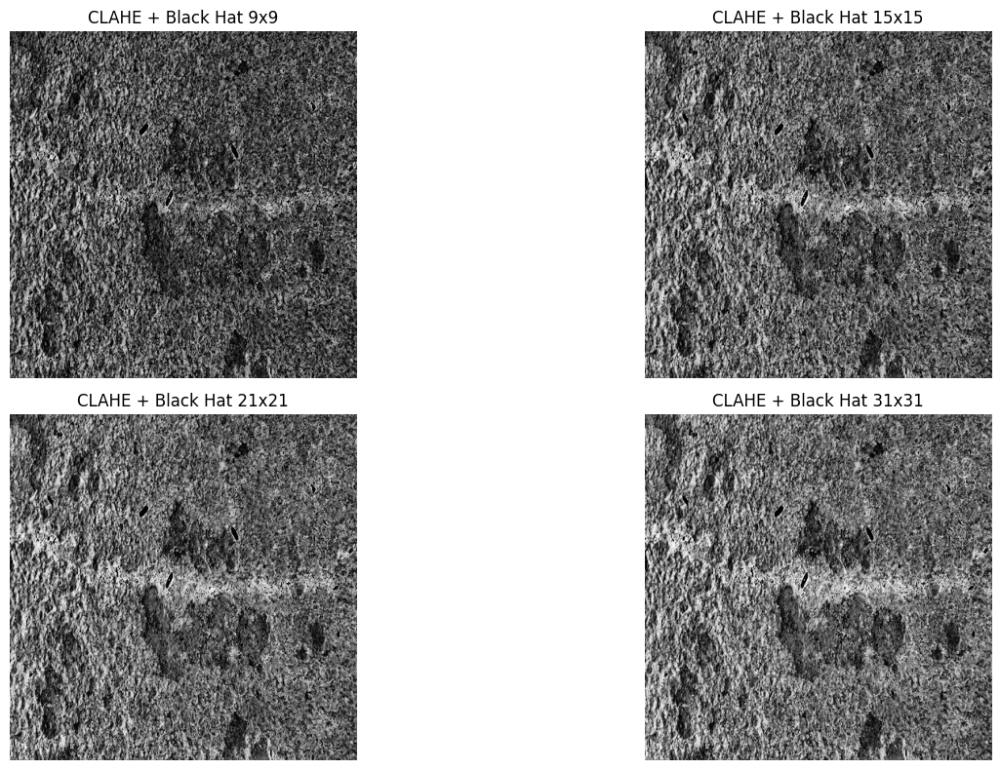

In [83]:
blackhat_images = [bh_9, bh_15, bh_21, bh_31]
titles = [
    "9x9",
    "15x15",
    "21x21",
    "31x31"
]

plt.figure(figsize=(16, 8))

for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.imshow(blackhat_images[i], cmap="gray")
    plt.title("CLAHE + Black Hat " + titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [84]:
blackhat_blur = cv2.GaussianBlur(
    blackhat,
    (5, 5),
    0
)
canny_blackhat = cv2.Canny(
    blackhat_blur,
    30,
    100
)

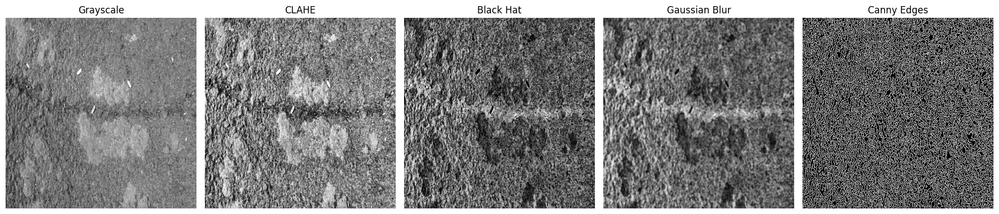

In [85]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 5, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(enhanced_gray, cmap="gray")
plt.title("CLAHE")
plt.axis("off")

plt.subplot(1, 5, 3)
plt.imshow(blackhat, cmap="gray")
plt.title("Black Hat")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(blackhat_blur, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(1, 5, 5)
plt.imshow(canny_blackhat, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.tight_layout()
plt.show()

In [87]:
# Resize image from 448x448 to 224x224
resized = cv2.resize(
    image,
    (224, 224),
    interpolation=cv2.INTER_AREA
)

print("Original shape:", image.shape)
print("Resized shape :", resized.shape)

Original shape: (448, 448, 3)
Resized shape : (224, 224, 3)


In [136]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# Select one crack image
filename = os.listdir("448/Cracks")[120]
image_path = os.path.join("448/Cracks", filename)

# Read image
image = cv2.imread(image_path)

# Convert BGR to RGB for displaying
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 1. Resize
resized = cv2.resize(image, (448, 448))

# 2. Grayscale
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

# 3. Strong Gaussian Blur
smooth = cv2.bilateralFilter(
    gray,
    d=9,
    sigmaColor=50,
    sigmaSpace=50
)

# 4. Black Hat
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (25, 25)
)

blackhat = cv2.morphologyEx(
    smooth,
    cv2.MORPH_BLACKHAT,
    kernel
)

# 5. Normalize
normalized = cv2.normalize(
    blackhat    ,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

# Reduce weak intensity values
intensity_threshold = 100
reduction_factor = 0.3

intensity_reduced = normalized.copy()

mask = intensity_reduced < intensity_threshold

intensity_reduced[mask] = (
    intensity_reduced[mask] * reduction_factor
).astype(np.uint8)

# 6. Small Gaussian Blur
final_blur = cv2.GaussianBlur(
    intensity_reduced,
    (3, 3),
    0
)

threshold_value, binary = cv2.threshold(
    normalized,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
print("Otsu selected threshold:", threshold_value)

# 7. Canny Edge Detection
canny = cv2.Canny(
    binary,
    100,
    200
)

# 8. Flatten Canny image
flattened = canny.flatten()

print("Original shape :", image.shape)
print("Canny shape    :", canny.shape)
print("Flattened shape:", flattened.shape)

Otsu selected threshold: 84.0
Original shape : (448, 448, 3)
Canny shape    : (448, 448)
Flattened shape: (200704,)


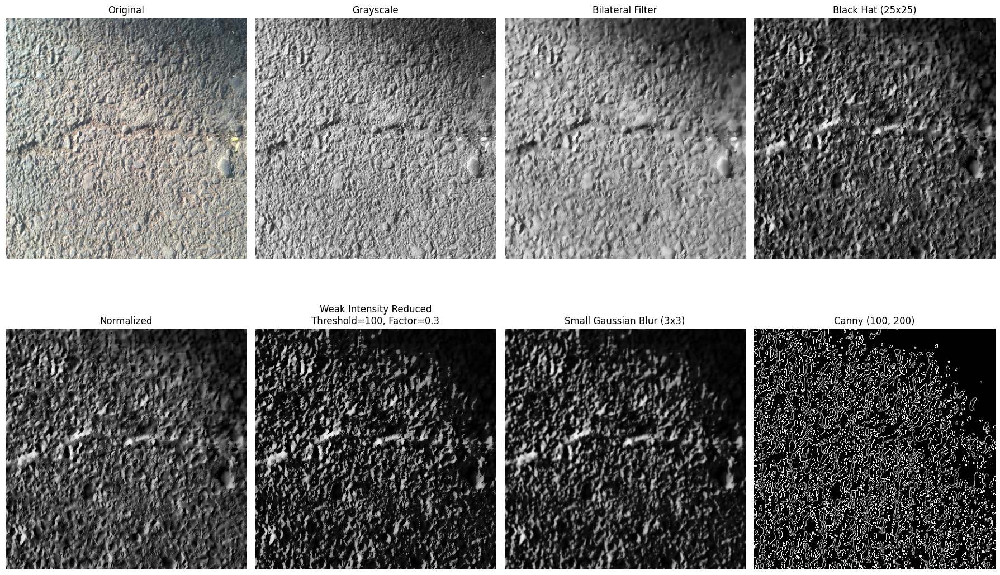

In [138]:
plt.figure(figsize=(18, 12))

# 1. Original
plt.subplot(2, 4, 1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

# 2. Grayscale
plt.subplot(2, 4, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

# 3. Bilateral Filter
plt.subplot(2, 4, 3)
plt.imshow(smooth, cmap="gray")
plt.title("Bilateral Filter")
plt.axis("off")

# 4. Black Hat
plt.subplot(2, 4, 4)
plt.imshow(blackhat, cmap="gray")
plt.title("Black Hat (25x25)")
plt.axis("off")

# 5. Normalized
plt.subplot(2, 4, 5)
plt.imshow(normalized, cmap="gray")
plt.title("Normalized")
plt.axis("off")

# 6. Reduced Weak Intensities
plt.subplot(2, 4, 6)
plt.imshow(intensity_reduced, cmap="gray")
plt.title("Weak Intensity Reduced\nThreshold=100, Factor=0.3")
plt.axis("off")

# 7. Small Gaussian Blur
plt.subplot(2, 4, 7)
plt.imshow(final_blur, cmap="gray")
plt.title("Small Gaussian Blur (3x3)")
plt.axis("off")

# 8. Canny
plt.subplot(2, 4, 8)
plt.imshow(canny, cmap="gray")
plt.title("Canny (100, 200)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [215]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# Parameters
BH_BLUR_SIGMA = 5
BH_KERNEL_SIZE = 21
BLACKHAT_THRESHOLD = 8
MIN_CRACK_LENGTH = 35

# Black Hat kernel
blackhat_kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (BH_KERNEL_SIZE, BH_KERNEL_SIZE)
)

# Closing kernel
close_kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (5, 5)
)

In [224]:
# Select one crack image
filename = os.listdir("448/Cracks")[100]
image_path = os.path.join("448/Cracks", filename)

# Read image
image = cv2.imread(image_path)

# Resize
image = cv2.resize(image, (448, 448))

# For displaying
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print("Image:", filename)
print("Shape:", gray.shape)

Image: IMG_20180514_170708710_HDR resized_448.jpg
Shape: (448, 448)


In [225]:
# Convert to float
g = gray.astype(np.float32)

# -----------------------------------
# 1. Remove uneven lighting
# -----------------------------------

background = cv2.GaussianBlur(
    g,
    (0, 0),
    30
)

flat = g - background

flat = np.clip(
    flat + 128,
    0,
    255
).astype(np.uint8)


# -----------------------------------
# 2. Remove asphalt grain
# -----------------------------------

median = cv2.medianBlur(
    flat,
    5
)

smooth = cv2.GaussianBlur(
    median,
    (0, 0),
    BH_BLUR_SIGMA
)


# -----------------------------------
# 3. Darken low-intensity regions
# -----------------------------------

shadow_threshold = 120
darken_factor = 0.4

shadow_reduced = smooth.copy()

dark_mask = shadow_reduced < shadow_threshold

shadow_reduced[dark_mask] = (
    shadow_reduced[dark_mask] * darken_factor
).astype(np.uint8)


# -----------------------------------
# 4. Invert image
# -----------------------------------

inverted = cv2.bitwise_not(shadow_reduced)


# -----------------------------------
# 5. Threshold inverted image
# -----------------------------------

THRESHOLD = 180

mask = cv2.threshold(
    inverted,
    THRESHOLD,
    255,
    cv2.THRESH_BINARY
)[1]


# -----------------------------------
# 6. Close small gaps
# -----------------------------------

close_kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (5, 5)
)

closed_mask = cv2.morphologyEx(
    mask,
    cv2.MORPH_CLOSE,
    close_kernel
)


# -----------------------------------
# 7. Keep only long components
# -----------------------------------

MIN_CRACK_LENGTH = 35

n, labels, stats, _ = cv2.connectedComponentsWithStats(
    closed_mask,
    connectivity=8
)

clean = np.zeros_like(closed_mask)

for i in range(1, n):

    width = stats[i, cv2.CC_STAT_WIDTH]
    height = stats[i, cv2.CC_STAT_HEIGHT]

    if max(width, height) >= MIN_CRACK_LENGTH:
        clean[labels == i] = 255

In [226]:
n, labels, stats, _ = cv2.connectedComponentsWithStats(
    closed_mask,
    connectivity=8
)

clean = np.zeros_like(closed_mask)

for i in range(1, n):

    width = stats[i, cv2.CC_STAT_WIDTH]
    height = stats[i, cv2.CC_STAT_HEIGHT]

    if max(width, height) >= MIN_CRACK_LENGTH:
        clean[labels == i] = 255

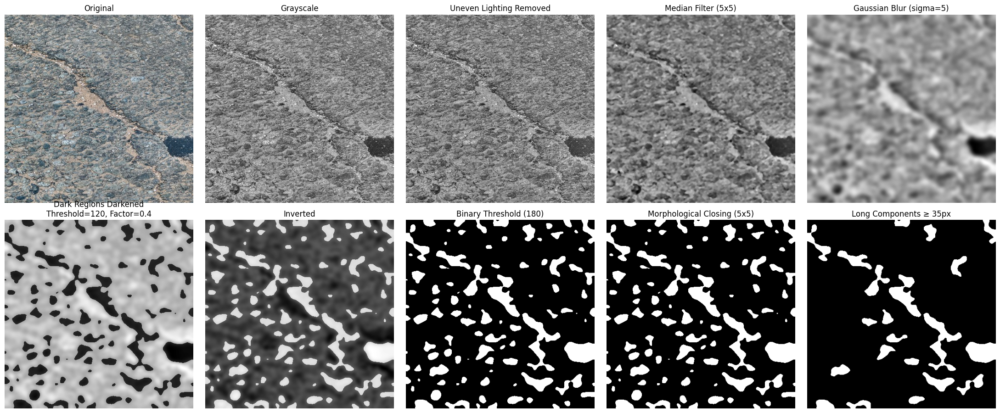

In [223]:
plt.figure(figsize=(22, 9))

# 1. Original
plt.subplot(2, 5, 1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

# 2. Grayscale
plt.subplot(2, 5, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

# 3. Uneven Lighting Removed
plt.subplot(2, 5, 3)
plt.imshow(flat, cmap="gray")
plt.title("Uneven Lighting Removed")
plt.axis("off")

# 4. Median Filter
plt.subplot(2, 5, 4)
plt.imshow(median, cmap="gray")
plt.title("Median Filter (5x5)")
plt.axis("off")

# 5. Gaussian Blur
plt.subplot(2, 5, 5)
plt.imshow(smooth, cmap="gray")
plt.title(f"Gaussian Blur (sigma={BH_BLUR_SIGMA})")
plt.axis("off")

# 6. Dark Regions Darkened
plt.subplot(2, 5, 6)
plt.imshow(shadow_reduced, cmap="gray")
plt.title(
    f"Dark Regions Darkened\n"
    f"Threshold={shadow_threshold}, Factor={darken_factor}"
)
plt.axis("off")

# 7. Inverted
plt.subplot(2, 5, 7)
plt.imshow(inverted, cmap="gray")
plt.title("Inverted")
plt.axis("off")

# 8. Threshold Mask
plt.subplot(2, 5, 8)
plt.imshow(mask, cmap="gray")
plt.title(f"Binary Threshold ({THRESHOLD})")
plt.axis("off")

# 9. Morphological Closing
plt.subplot(2, 5, 9)
plt.imshow(closed_mask, cmap="gray")
plt.title("Morphological Closing (5x5)")
plt.axis("off")

# 10. Long Components
plt.subplot(2, 5, 10)
plt.imshow(clean, cmap="gray")
plt.title(
    f"Long Components ≥ {MIN_CRACK_LENGTH}px"
)
plt.axis("off")

plt.tight_layout()
plt.show()

In [232]:
# Final preprocessing parameters

BLUR_SIGMA = 5

shadow_threshold = 120
darken_factor = 0.4

THRESHOLD = 180
MIN_CRACK_LENGTH = 35

close_kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (5, 5)
)


def preprocess_crack_image(gray):

    # 1. Remove uneven lighting
    g = gray.astype(np.float32)

    background = cv2.GaussianBlur(
        g,
        (0, 0),
        30
    )

    flat = g - background

    flat = np.clip(
        flat + 128,
        0,
        255
    ).astype(np.uint8)


    # 2. Median filter
    median = cv2.medianBlur(
        flat,
        5
    )


    # 3. Gaussian blur
    smooth = cv2.GaussianBlur(
        median,
        (0, 0),
        BLUR_SIGMA
    )


    # 4. Darken low-intensity regions
    shadow_reduced = smooth.copy()

    dark_mask = shadow_reduced < shadow_threshold

    shadow_reduced[dark_mask] = (
        shadow_reduced[dark_mask] * darken_factor
    ).astype(np.uint8)


    # 5. Invert
    inverted = cv2.bitwise_not(
        shadow_reduced
    )


    # 6. Threshold
    mask = cv2.threshold(
        inverted,
        THRESHOLD,
        255,
        cv2.THRESH_BINARY
    )[1]


    # 7. Morphological closing
    closed_mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        close_kernel
    )


    # 8. Keep long components
    n, labels, stats, _ = cv2.connectedComponentsWithStats(
        closed_mask,
        connectivity=8
    )

    clean = np.zeros_like(closed_mask)

    for i in range(1, n):

        width = stats[i, cv2.CC_STAT_WIDTH]
        height = stats[i, cv2.CC_STAT_HEIGHT]

        if max(width, height) >= MIN_CRACK_LENGTH:
            clean[labels == i] = 255


    return inverted, clean

In [233]:
def extract_features(gray):

    # Final preprocessing
    inverted, clean = preprocess_crack_image(gray)


    # --------------------------
    # Original intensity features
    # --------------------------

    mean_brightness = np.mean(gray)
    contrast = np.std(gray)

    dark_pixel_ratio = np.mean(gray < 50)
    bright_pixel_ratio = np.mean(gray > 200)

    min_intensity = np.min(gray)
    max_intensity = np.max(gray)
    median_intensity = np.median(gray)


    # --------------------------
    # Final mask features
    # --------------------------

    crack_pixel_count = np.sum(clean > 0)

    crack_pixel_ratio = np.mean(clean > 0)


    # Connected components
    n, labels, stats, _ = cv2.connectedComponentsWithStats(
        clean,
        connectivity=8
    )

    areas = stats[1:, cv2.CC_STAT_AREA]


    num_components = len(areas)

    largest_component = (
        areas.max()
        if len(areas) > 0
        else 0
    )


    return [
        mean_brightness,
        contrast,
        dark_pixel_ratio,
        bright_pixel_ratio,
        min_intensity,
        max_intensity,
        median_intensity,
        crack_pixel_count,
        crack_pixel_ratio,
        num_components,
        largest_component
    ]

In [234]:
features = []
labels = []

# -------------------------
# Crack images
# -------------------------

for filename in os.listdir("448/Cracks"):

    path = os.path.join(
        "448/Cracks",
        filename
    )

    image = cv2.imread(path)

    if image is not None:

        image = cv2.resize(
            image,
            (448, 448)
        )

        gray = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2GRAY
        )

        image_features = extract_features(gray)

        features.append(image_features)

        # 1 = Crack
        labels.append(1)


# -------------------------
# Non-Crack images
# -------------------------

for filename in os.listdir("448/NonCracks"):

    path = os.path.join(
        "448/NonCracks",
        filename
    )

    image = cv2.imread(path)

    if image is not None:

        image = cv2.resize(
            image,
            (448, 448)
        )

        gray = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2GRAY
        )

        image_features = extract_features(gray)

        features.append(image_features)

        # 0 = Non-Crack
        labels.append(0)

In [235]:
import pandas as pd

feature_names = [
    "mean_brightness",
    "contrast",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "min_intensity",
    "max_intensity",
    "median_intensity",
    "crack_pixel_count",
    "crack_pixel_ratio",
    "num_components",
    "largest_component"
]

feature_df = pd.DataFrame(
    features,
    columns=feature_names
)

feature_df["label"] = labels

feature_df.head()

,mean_brightness,contrast,dark_pixel_ratio,bright_pixel_ratio,min_intensity,max_intensity,median_intensity,crack_pixel_count,crack_pixel_ratio,num_components,largest_component,label
0,122.096147,38.014345,0.016333,0.026676,0,255,121.0,16233,0.080880,21,2524,1
1,131.822704,29.319148,0.006741,0.011759,0,255,133.0,20282,0.101054,14,5920,1
2,121.171217,35.572563,0.024992,0.020712,0,255,120.0,21442,0.106834,11,7907,1
3,130.117701,32.745086,0.008889,0.014917,1,255,131.0,19834,0.098822,18,5364,1
4,131.079998,33.199356,0.009741,0.016791,0,255,132.0,14827,0.073875,14,3011,1


In [236]:
print("Feature table shape:", feature_df.shape)

print("\nLabel distribution:")
print(feature_df["label"].value_counts())

Feature table shape: (400, 12)

Label distribution:
label
1    200
0    200
Name: count, dtype: int64


In [237]:
feature_df.to_csv(
    "image_features.csv",
    index=False
)

print("Feature table saved.")

Feature table saved.


In [238]:
X = feature_df.drop("label", axis=1)
y = feature_df["label"]

In [239]:
X = feature_df.drop("label", axis=1)
y = feature_df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 11)
y shape: (400,)


In [240]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (320, 11)
X_test : (80, 11)
y_train: (320,)
y_test : (80,)


In [251]:
import time
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=1000)
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=4, min_samples_leaf=5, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=6, min_samples_leaf=3,
        max_features="sqrt", oob_score=True, random_state=42
    ),
}

results_regularized = {}

for name, model in models.items():
    start = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - start

    start = time.perf_counter()
    y_pred = model.predict(X_test)
    predict_time = time.perf_counter() - start

    results_regularized[name] = {
        "model": model,
        "predictions": y_pred,
        "train_time": train_time,
        "predict_time": predict_time,
    }

    print(name)
    print(f"Training time  : {train_time:.4f}s")
    print(f"Prediction time: {predict_time:.4f}s")
    if name == "Random Forest":
        print(f"OOB accuracy   : {model.oob_score_:.4f}")
    print()

Logistic Regression
Training time  : 0.0375s
Prediction time: 0.0022s

Decision Tree
Training time  : 0.0130s
Prediction time: 0.0014s

Random Forest
Training time  : 0.4292s
Prediction time: 0.0098s
OOB accuracy   : 0.9531



In [252]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

for name, result in results_regularized.items():

    y_pred = result["predictions"]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)

    print("=" * 50)
    print(name)
    print("=" * 50)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-Score :", f1)

    print("\nConfusion Matrix:")
    print(cm)

    print("\nTraining Time :", result["train_time"])
    print("Prediction Time:", result["predict_time"])

    print()

Logistic Regression
Accuracy : 0.9375
Precision: 0.9069767441860465
Recall   : 0.975
F1-Score : 0.9397590361445783

Confusion Matrix:
[[36  4]
 [ 1 39]]

Training Time : 0.0375313999975333
Prediction Time: 0.002225799995358102

Decision Tree
Accuracy : 0.9
Precision: 0.8636363636363636
Recall   : 0.95
F1-Score : 0.9047619047619048

Confusion Matrix:
[[34  6]
 [ 2 38]]

Training Time : 0.012956400008988567
Prediction Time: 0.0014494000060949475

Random Forest
Accuracy : 0.95
Precision: 0.95
Recall   : 0.95
F1-Score : 0.95

Confusion Matrix:
[[38  2]
 [ 2 38]]

Training Time : 0.4292406000022311
Prediction Time: 0.009785600006580353



In [253]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

evaluation_results = []

for name, result in results_regularized.items():

    y_pred = result["predictions"]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    evaluation_results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        result["train_time"],
        result["predict_time"]
    ])

In [254]:
results_df = pd.DataFrame(
    evaluation_results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "Training Time",
        "Prediction Time"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,Training Time,Prediction Time
0,Logistic Regression,0.9375,0.906977,0.975,0.939759,0.037531,0.002226
1,Decision Tree,0.9000,0.863636,0.950,0.904762,0.012956,0.001449
2,Random Forest,0.9500,0.950000,0.950,0.950000,0.429241,0.009786


In [255]:
from sklearn.metrics import confusion_matrix

for name, result in results_regularized.items():

    y_pred = result["predictions"]

    cm = confusion_matrix(y_test, y_pred)

    print(name)
    print(cm)
    print()

Logistic Regression
[[36  4]
 [ 1 39]]

Decision Tree
[[34  6]
 [ 2 38]]

Random Forest
[[38  2]
 [ 2 38]]



In [256]:
dt_pred = results_regularized["Decision Tree"]["predictions"]
rf_pred = results_regularized["Random Forest"]["predictions"]

print("Same predictions:", np.array_equal(dt_pred, rf_pred))

print(
    "Number of different predictions:",
    np.sum(dt_pred != rf_pred)
)

Same predictions: False
Number of different predictions: 6


In [257]:
evaluation_results = []

for name, result in results_regularized.items():

    model = result["model"]
    y_pred = result["predictions"]

    # Training prediction
    y_train_pred = model.predict(X_train)

    train_accuracy = accuracy_score(
        y_train,
        y_train_pred
    )

    # Testing metrics
    test_accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    evaluation_results.append([
        name,
        train_accuracy,
        test_accuracy,
        precision,
        recall,
        f1,
        train_accuracy - test_accuracy,
        result["train_time"],
        result["predict_time"]
    ])

In [258]:
results_df = pd.DataFrame(
    evaluation_results,
    columns=[
        "Model",
        "Train Accuracy",
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "Train-Test Gap",
        "Training Time",
        "Prediction Time"
    ]
)

results_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score,Train-Test Gap,Training Time,Prediction Time
0,Logistic Regression,0.925000,0.9375,0.906977,0.975,0.939759,-0.012500,0.037531,0.002226
1,Decision Tree,0.940625,0.9000,0.863636,0.950,0.904762,0.040625,0.012956,0.001449
2,Random Forest,0.987500,0.9500,0.950000,0.950,0.950000,0.037500,0.429241,0.009786


In [271]:
import time

# 1) Baseline extraction time (ms per image)
start = time.perf_counter()
for g in gray_images:
    baseline_features(g)
t_base = (time.perf_counter() - start) / len(gray_images) * 1000

# 2) Mask features (uses your preprocess_crack_image)
MASK = ["crack_pixel_count", "crack_pixel_ratio",
        "num_components", "largest_component"]

def mask_features(gray):
    _, clean = preprocess_crack_image(gray)
    count = int(np.sum(clean > 0))
    _, _, stats, _ = cv2.connectedComponentsWithStats(clean, connectivity=8)
    areas = stats[1:, cv2.CC_STAT_AREA]
    return [count, count / clean.size, len(areas),
            int(areas.max()) if len(areas) else 0]

start = time.perf_counter()
mask_rows = [mask_features(g) for g in gray_images]
t_mask = (time.perf_counter() - start) / len(gray_images) * 1000

X_mask = pd.DataFrame(mask_rows, columns=MASK)

# 3) Improved = baseline + mask; compact = drop constant/redundant columns
X_full = pd.concat([X_base, X_mask], axis=1)
X_comp = X_full.drop(columns=["min_intensity", "max_intensity",
                              "crack_pixel_count", "edge_count"])
t_full = t_base + t_mask

X_full.assign(label=y_base).to_csv("image_features_improved.csv", index=False)

print(f"Baseline: {X_base.shape[1]} features | {t_base:.2f} ms/img")
print(f"Improved: {X_full.shape[1]} features | {t_full:.2f} ms/img")
print(f"Compact : {X_comp.shape[1]} features | {t_full:.2f} ms/img")

X_full.assign(label=y_base).groupby("label")[MASK].mean().round(3)

Baseline: 9 features | 10.79 ms/img
Improved: 13 features | 27.98 ms/img
Compact : 9 features | 27.98 ms/img


,crack_pixel_count,crack_pixel_ratio,num_components,largest_component
label,,,,
0,6635.900,0.033,6.57,1698.435
1,24657.965,0.123,17.92,6874.195


In [272]:
from sklearn.base import clone
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate

feature_sets = {
    "Baseline": (X_base, t_base),
    "Improved": (X_full, t_full),
    "Improved compact": (X_comp, t_full),
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

rows = []
for set_name, (X_, t_extract) in feature_sets.items():
    for name, model in base_models.items():
        r = cross_validate(clone(model), X_, y_base, cv=cv,
                           scoring=["accuracy", "f1"],
                           return_train_score=True, n_jobs=-1)
        rows.append([set_name, name, X_.shape[1], round(t_extract, 2),
                     r["train_accuracy"].mean(), r["test_accuracy"].mean(),
                     r["test_accuracy"].std(), r["test_f1"].mean(),
                     r["fit_time"].mean(), r["score_time"].mean()])

compare_df = pd.DataFrame(rows, columns=[
    "Feature set", "Model", "# Features", "Extract ms/img",
    "Train Acc", "CV Acc", "CV Std", "CV F1", "Fit time (s)", "Predict time (s)"])
compare_df.to_csv("comparison_results.csv", index=False)
compare_df.round(4)

,Feature set,Model,# Features,Extract ms/img,Train Acc,CV Acc,CV Std,CV F1,Fit time (s),Predict time (s)
0,Baseline,Logistic Regression,9,10.79,0.9070,0.9000,0.0294,0.9015,0.0178,0.0091
1,Baseline,Decision Tree,9,10.79,0.9562,0.9295,0.0257,0.9295,0.0059,0.0068
2,Baseline,Random Forest,9,10.79,0.9746,0.9430,0.0245,0.9432,0.8073,0.0291
3,Improved,Logistic Regression,13,27.98,0.9351,0.9250,0.0240,0.9256,0.0665,0.0144
4,Improved,Decision Tree,13,27.98,0.9548,0.8955,0.0381,0.8954,0.0243,0.0186
5,Improved,Random Forest,13,27.98,0.9829,0.9450,0.0226,0.9455,0.6190,0.0260
6,Improved compact,Logistic Regression,9,27.98,0.9410,0.9320,0.0206,0.9328,0.0166,0.0066
7,Improved compact,Decision Tree,9,27.98,0.9550,0.8945,0.0394,0.8940,0.0055,0.0070
8,Improved compact,Random Forest,9,27.98,0.9829,0.9460,0.0257,0.9462,0.5377,0.0220


# Part B

In [273]:
import pandas as pd
import numpy as np

emails = pd.read_csv("emails.csv")
print("Shape:", emails.shape)

y_text = emails["Prediction"].values
X_counts = emails.drop(columns=["Email No.", "Prediction"])

print("Class distribution:")
print(pd.Series(y_text).value_counts().rename({0: "non-spam", 1: "spam"}))
print("Spam share: %.1f%%" % (100 * y_text.mean()))

# Duplicates (identical word counts and label)
dup = X_counts.duplicated().sum()
print("Duplicate rows:", dup)

# Remove duplicates before splitting to avoid train/test leakage
mask = ~X_counts.duplicated()
X_counts = X_counts[mask].reset_index(drop=True)
y_text = y_text[mask.values]
print("After dedup:", X_counts.shape, "| spam share: %.1f%%" % (100 * y_text.mean()))

Shape: (5172, 3002)
Class distribution:
non-spam    3672
spam        1500
Name: count, dtype: int64
Spam share: 29.0%
Duplicate rows: 541
After dedup: (4631, 3000) | spam share: 31.5%


In [277]:
import time
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split

Xc_train, Xc_test, yt_train, yt_test = train_test_split(
    X_counts, y_text, test_size=0.2, stratify=y_text, random_state=42
)

Xc_train = csr_matrix(Xc_train.values)
Xc_test = csr_matrix(Xc_test.values)

print("Train:", Xc_train.shape, "| Test:", Xc_test.shape)
print("Spam share train/test: %.3f / %.3f" % (yt_train.mean(), yt_test.mean()))
print("Non-zero entries (train): %d (%.2f%% dense)" % (
    Xc_train.nnz, 100 * Xc_train.nnz / np.prod(Xc_train.shape)))

Train: (3704, 3000) | Test: (927, 3000)
Spam share train/test: 0.316 / 0.315
Non-zero entries (train): 656646 (5.91% dense)


In [278]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

text_models = {
    "Multinomial NB": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=2000),
}

rows = []
for name, model in text_models.items():
    start = time.perf_counter()
    model.fit(Xc_train, yt_train)
    train_time = time.perf_counter() - start

    start = time.perf_counter()
    pred = model.predict(Xc_test)
    predict_time = time.perf_counter() - start

    train_acc = accuracy_score(yt_train, model.predict(Xc_train))
    rows.append([name, Xc_train.shape[1], train_acc,
                 accuracy_score(yt_test, pred),
                 precision_score(yt_test, pred), recall_score(yt_test, pred),
                 f1_score(yt_test, pred), train_time, predict_time])

    print(name)
    print(confusion_matrix(yt_test, pred), "\n")

text_results_df = pd.DataFrame(rows, columns=[
    "Model", "# Features", "Train Acc", "Test Acc", "Precision",
    "Recall", "F1", "Train Time (s)", "Predict Time (s)"])
text_results_df.to_csv("text_count_results.csv", index=False)
text_results_df.round(4)

Multinomial NB
[[602  33]
 [ 12 280]] 

Logistic Regression
[[622  13]
 [ 11 281]] 



,Model,# Features,Train Acc,Test Acc,Precision,Recall,F1,Train Time (s),Predict Time (s)
0,Multinomial NB,3000,0.9471,0.9515,0.8946,0.9589,0.9256,0.0209,0.0062
1,Logistic Regression,3000,0.9995,0.9741,0.9558,0.9623,0.9590,3.8406,0.0039


In [280]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv_text = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grids = {
    "Multinomial NB": (MultinomialNB(),
                       {"alpha": [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]}),
    "Logistic Regression": (LogisticRegression(max_iter=2000),
                            {"C": [0.01, 0.1, 1, 10, 100]}),
}

searches = {}
for name, (estimator, grid) in param_grids.items():
    gs = GridSearchCV(estimator, grid, cv=cv_text, scoring="f1",
                      n_jobs=-1, return_train_score=True)
    start = time.perf_counter()
    gs.fit(Xc_train, yt_train)
    search_time = time.perf_counter() - start
    searches[name] = gs

    print(f"{name} | best: {gs.best_params_} | CV F1: {gs.best_score_:.4f} "
          f"| search time: {search_time:.1f}s")
    print(pd.DataFrame(gs.cv_results_)[
        ["params", "mean_train_score", "mean_test_score", "std_test_score"]
    ].round(4).to_string(index=False), "\n")

Multinomial NB | best: {'alpha': 0.01} | CV F1: 0.9262 | search time: 12.6s
         params  mean_train_score  mean_test_score  std_test_score
{'alpha': 0.01}            0.9341           0.9262          0.0087
{'alpha': 0.03}            0.9314           0.9238          0.0075
 {'alpha': 0.1}            0.9284           0.9204          0.0067
 {'alpha': 0.3}            0.9257           0.9174          0.0092
 {'alpha': 1.0}            0.9206           0.9109          0.0098
 {'alpha': 3.0}            0.9130           0.9040          0.0096 

Logistic Regression | best: {'C': 1} | CV F1: 0.9442 | search time: 30.2s
     params  mean_train_score  mean_test_score  std_test_score
{'C': 0.01}            0.9642           0.9305          0.0083
 {'C': 0.1}            0.9926           0.9441          0.0080
   {'C': 1}            0.9996           0.9442          0.0089
  {'C': 10}            1.0000           0.9389          0.0090
 {'C': 100}            1.0000           0.9432          0.0107 


In [281]:
tuned_rows = []
for name, gs in searches.items():
    best = gs.best_estimator_            # already refit on the full train split

    start = time.perf_counter()
    pred = best.predict(Xc_test)
    predict_time = time.perf_counter() - start

    tuned_rows.append([name, Xc_train.shape[1],
                       accuracy_score(yt_train, best.predict(Xc_train)),
                       accuracy_score(yt_test, pred),
                       precision_score(yt_test, pred),
                       recall_score(yt_test, pred),
                       f1_score(yt_test, pred),
                       gs.refit_time_, predict_time])
    print(name, gs.best_params_)
    print(confusion_matrix(yt_test, pred), "\n")

cols = ["Model", "# Features", "Train Acc", "Test Acc", "Precision",
        "Recall", "F1", "Train Time (s)", "Predict Time (s)"]
tuned_df = pd.DataFrame(tuned_rows, columns=cols)

comparison = pd.concat([
    text_results_df.assign(Setting="Default"),
    tuned_df.assign(Setting="Tuned"),
]).sort_values(["Model", "Setting"])
comparison.to_csv("text_tuning_results.csv", index=False)
comparison.round(4)

Multinomial NB {'alpha': 0.01}
[[607  28]
 [ 12 280]] 

Logistic Regression {'C': 1}
[[622  13]
 [ 11 281]] 



,Model,# Features,Train Acc,Test Acc,Precision,Recall,F1,Train Time (s),Predict Time (s),Setting
1,Logistic Regression,3000,0.9995,0.9741,0.9558,0.9623,0.9590,3.8406,0.0039,Default
1,Logistic Regression,3000,0.9995,0.9741,0.9558,0.9623,0.9590,1.6414,0.0020,Tuned
0,Multinomial NB,3000,0.9471,0.9515,0.8946,0.9589,0.9256,0.0209,0.0062,Default
0,Multinomial NB,3000,0.9565,0.9569,0.9091,0.9589,0.9333,0.0168,0.0045,Tuned
